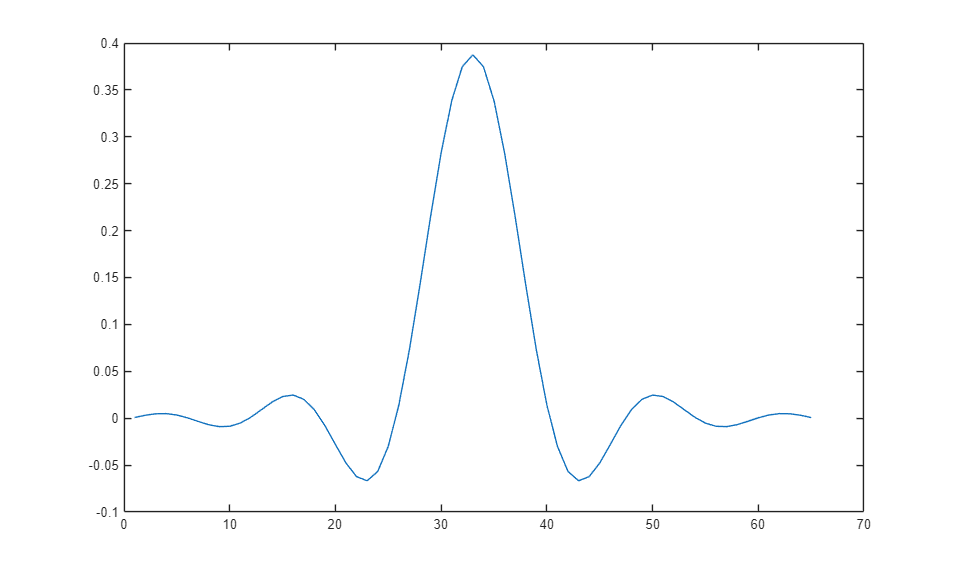

In [1]:
alpha = 0.35;    % Match cellular standards
span = 8;        % Slightly wider span for accuracy
sps = 8;         % High fidelity sampling

h = rcosdesign(alpha, span, sps, 'sqrt'); % 'sqrt' for Root Raised Cosine (standard)


figure();
plot(h);

In [2]:
M = 64;

data = randi([0 M-1], 10000, 1);
qamSig = qammod(data, M);

% 2. Apply the Raised Cosine Filter
% This automatically upsamples by 'sps' and applies the filter 'h'
txWaveform = upfirdn(qamSig, h, sps);

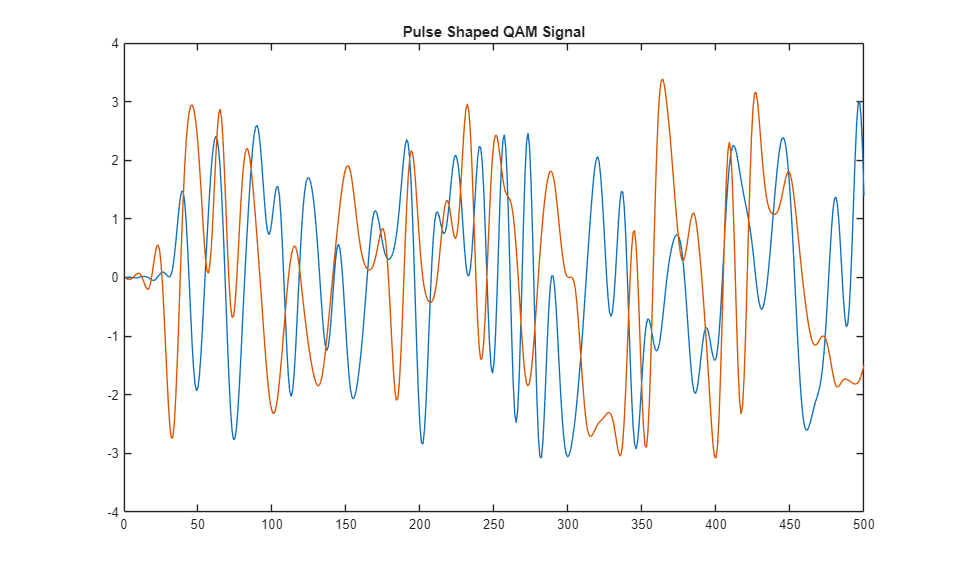

In [3]:


N = 500;



% 3. Plot a snippet of the waveform
figure;
plot(real(txWaveform(1:N))); % Viewing In-Phase component only

hold on;

plot(imag(txWaveform(1:N))); % Viewing In-Phase component only

title('Pulse Shaped QAM Signal');

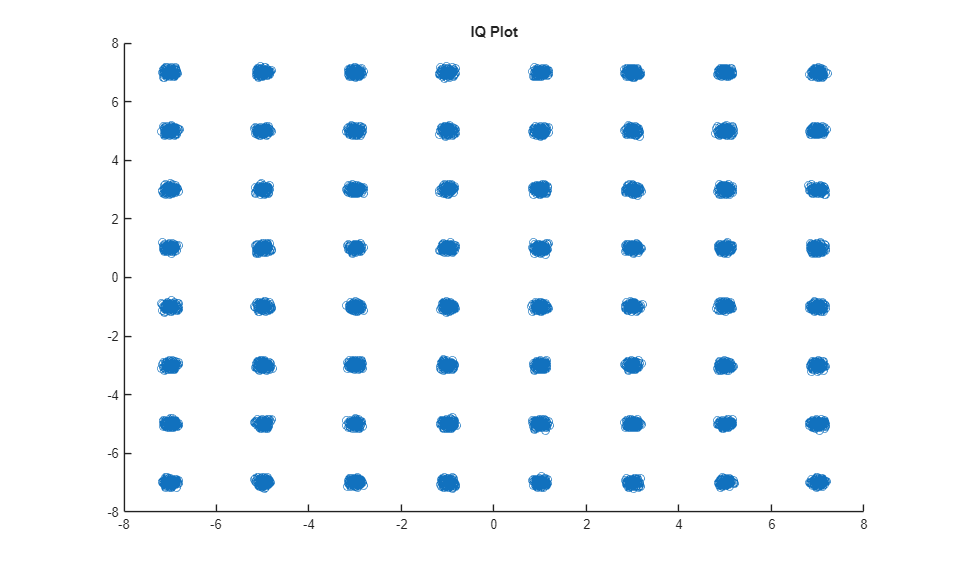

In [4]:
numSymbols = length(data);

rxFiltered = upfirdn(txWaveform, h, 1); 

% 6. Synchronize and Downsample
% The total delay is the sum of both filters.
% Tx Delay = (span*sps)/2
% Rx Delay = (span*sps)/2
% Total Delay = span * sps
totalDelay = span * sps;

% Start reading after the delay to skip the "ramp up"
rxSampled = rxFiltered(totalDelay + 1 : sps : end);

% 7. *** THE FIX FOR THE CENTER DOT ***
% 'upfirdn' outputs a longer signal than input to capture the "ramp down".
% These extra samples trail off to zero, causing the dot at 0,0.
% We simply truncate the vector to the original number of symbols.
rxRecovered = rxSampled(1:numSymbols);

% 8. Plot
figure();
scatter(real(rxRecovered), imag(rxRecovered))
title('IQ Plot');

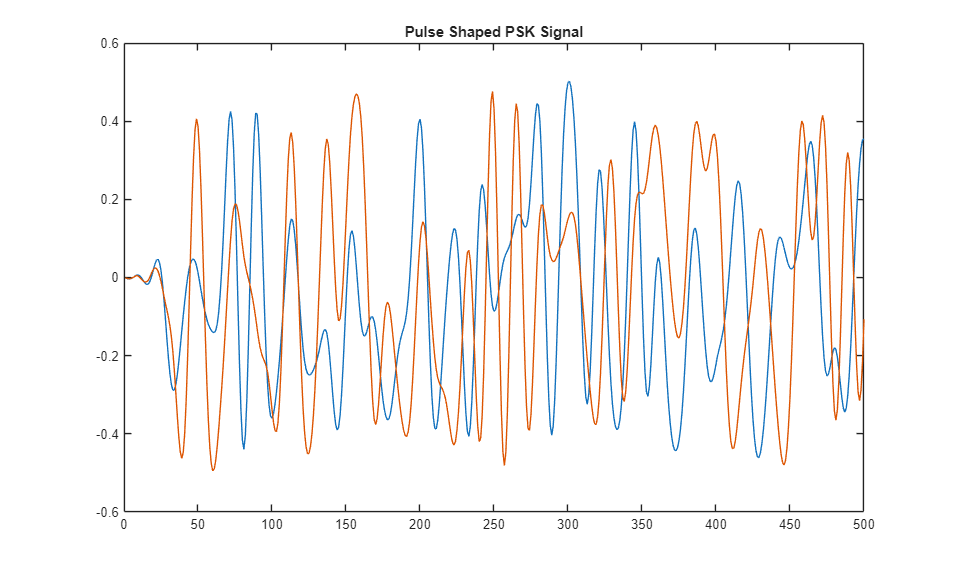

In [18]:
M = 64;

pskSig = pskmod(data, M);

txWaveform = upfirdn(pskSig, h, sps);


N = 500;



% 3. Plot a snippet of the waveform
figure;
plot(real(txWaveform(1:N))); % Viewing In-Phase component only

hold on;

plot(imag(txWaveform(1:N))); % Viewing In-Phase component only

title('Pulse Shaped PSK Signal');


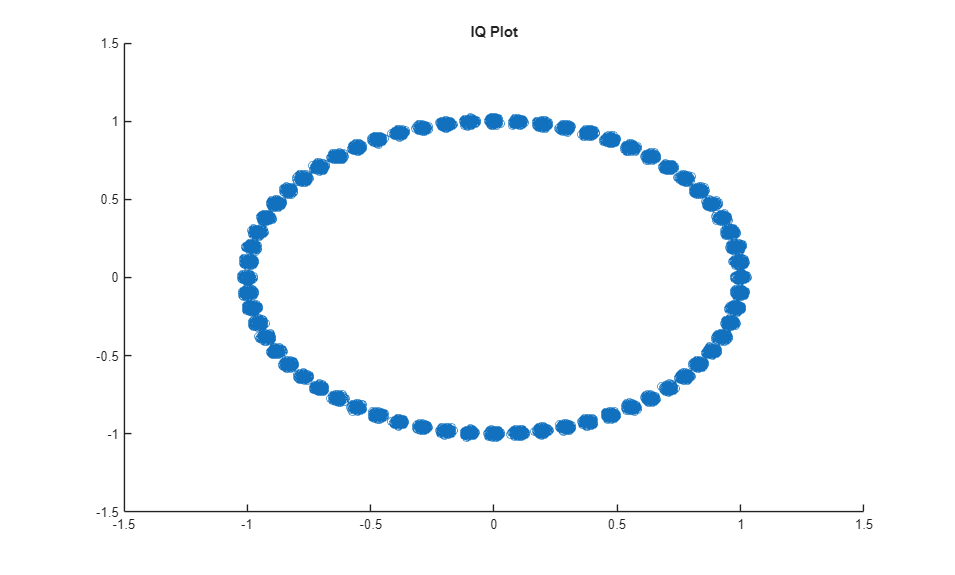

In [19]:
numSymbols = length(data);

rxFiltered = upfirdn(txWaveform, h, 1); 


totalDelay = span * sps;

rxSampled = rxFiltered(totalDelay + 1 : sps : end);


rxRecovered = rxSampled(1:numSymbols);

figure();
scatter(real(rxRecovered), imag(rxRecovered))
title('IQ Plot');